# Adult Census Income — Boostwatch Analysis

Binary classification on the [Adult Census Income](https://archive.ics.uci.edu/dataset/2/adult) dataset — a classic benchmark for gradient boosting.

| Property | Value |
|---|---|
| **Rows** | 48,842 |
| **Features** | 14 (continuous + categorical) |
| **Task** | Binary classification: income > $50K/year |
| **Source** | UCI ML Repository via `sklearn.datasets.fetch_openml` |

## What this notebook covers
1. Downloading & exploring the dataset (no authentication needed)
2. Preprocessing — encoding, handling missing values
3. Training a LightGBM model with **boostwatch** monitoring
4. Feature importance & usage analysis across all 14 features
5. Tree complexity evolution during training
6. Prediction confidence analysis
7. Split depth distribution
8. Cross-framework comparison: **LightGBM** vs **sklearn GradientBoosting**

## Setup

In [1]:
# Uncomment to install:
# pip install boostwatch[lightgbm]

%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score
from sklearn.datasets import fetch_openml
import lightgbm as lgb

import sys, os
sys.path.insert(0, os.path.abspath('..'))

from boostwatch import watch
from boostwatch.viz.themes import apply_theme
from boostwatch.analysis.tree_analysis import (
    compute_tree_stats,
    compute_split_depth_distribution,
    compute_leaf_distribution,
)

apply_theme('default')
print(f'LightGBM {lgb.__version__}')
print('Boostwatch ready')

LightGBM 4.6.0
Boostwatch ready


## 1. Download the Dataset

`fetch_openml` caches the data locally (`~/scikit_learn_data/`) after the first download — no authentication required.

In [2]:
print('Downloading Adult Census Income from OpenML...')
adult = fetch_openml('adult', version=2, as_frame=True, parser='auto')
X_raw = adult.data.copy()
y_raw = adult.target.copy()

print(f'Shape: {X_raw.shape}')
print(f'\nFeature dtypes:')
print(X_raw.dtypes.to_string())
print(f'\nTarget classes: {sorted(y_raw.unique().tolist())}')

Shape: (48842, 14)

Feature dtypes:
age                  int64
workclass         category
fnlwgt               int64
education         category
education-num        int64
marital-status    category
occupation        category
relationship      category
race              category
sex               category
capital-gain         int64
capital-loss         int64
hours-per-week       int64
native-country    category

Target classes: ['<=50K', '>50K']


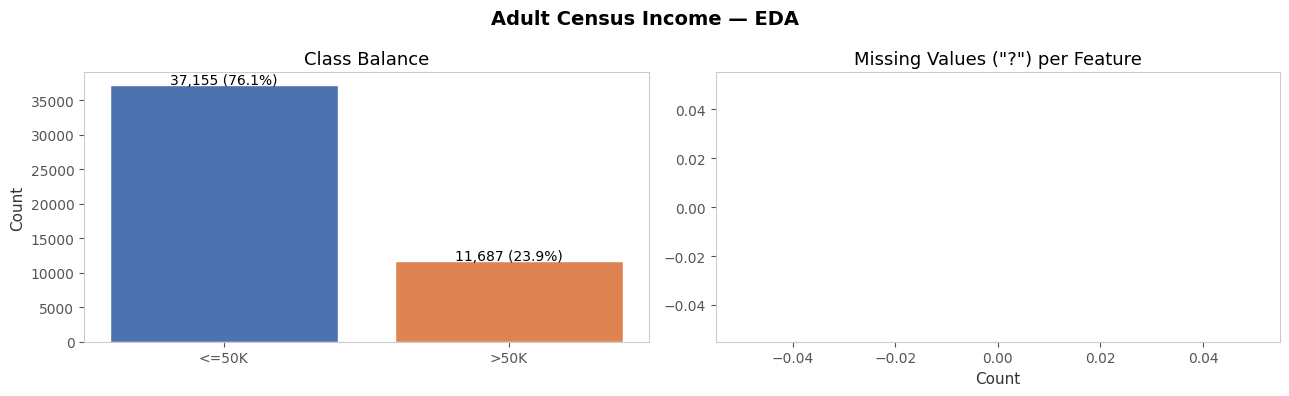


Continuous features: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Categorical features: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


In [3]:
# Quick EDA
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Class balance
vc = y_raw.value_counts()
axes[0].bar(vc.index, vc.values, color=['#4c72b0', '#dd8452'], edgecolor='white')
axes[0].set_title('Class Balance', fontsize=13)
axes[0].set_ylabel('Count')
for i, (k, v) in enumerate(vc.items()):
    axes[0].text(i, v + 200, f'{v:,} ({v/len(y_raw)*100:.1f}%)', ha='center', fontsize=10)

# Missing values
miss = (X_raw == '?').sum().sort_values(ascending=False)
miss = miss[miss > 0]
axes[1].barh(miss.index, miss.values, color='#c44e52', edgecolor='white')
axes[1].set_title('Missing Values ("?") per Feature', fontsize=13)
axes[1].set_xlabel('Count')
for i, v in enumerate(miss.values):
    axes[1].text(v + 20, i, str(v), va='center', fontsize=10)

plt.suptitle('Adult Census Income — EDA', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nContinuous features: {list(X_raw.select_dtypes(include="number").columns)}')
print(f'Categorical features: {list(X_raw.select_dtypes(exclude="number").columns)}')

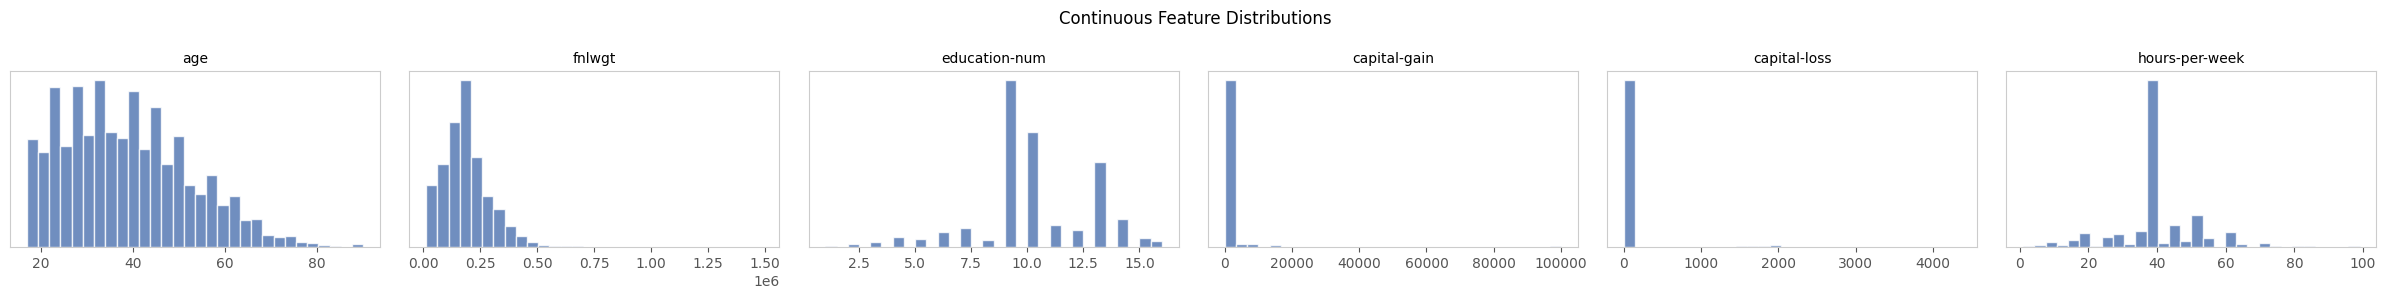

In [4]:
# Distribution of key continuous features
cont_cols = list(X_raw.select_dtypes(include='number').columns)
fig, axes = plt.subplots(1, len(cont_cols), figsize=(4 * len(cont_cols), 3))
for ax, col in zip(axes, cont_cols):
    ax.hist(X_raw[col].dropna(), bins=30, color='#4c72b0', alpha=0.8, edgecolor='white')
    ax.set_title(col, fontsize=10)
    ax.set_yticks([])
plt.suptitle('Continuous Feature Distributions', fontsize=12)
plt.tight_layout()
plt.show()

## 2. Preprocessing

- Replace `'?'` with `NaN`, then drop rows with missing values
- Encode categorical columns with `OrdinalEncoder`
- Map target to binary: `1` = income >50K, `0` = income ≤50K

In [5]:
X = X_raw.replace('?', float('nan')).dropna()
y_full = y_raw.loc[X.index]

# Encode target
y = (y_full.str.strip().str.replace('.', '', regex=False) == '>50K').astype(int)

# Encode categoricals
cat_cols = list(X.select_dtypes(exclude='number').columns)
num_cols = list(X.select_dtypes(include='number').columns)
feature_names = num_cols + cat_cols

enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_enc = X.copy()
X_enc[cat_cols] = enc.fit_transform(X[cat_cols])
X_enc = X_enc[feature_names].astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X_enc, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Positive rate — Train: {y_train.mean():.3f}  |  Test: {y_test.mean():.3f}')
print(f'\nFeatures ({len(feature_names)}): {feature_names}')

Train: (36177, 14)  |  Test: (9045, 14)
Positive rate — Train: 0.248  |  Test: 0.248

Features (14): ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week', 'workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


## 3. Training with Boostwatch (LightGBM)

`watch(model)` auto-detects LightGBM and returns a `LightGBMObserver`.
Pass `observer.callbacks()` directly into `model.fit()` — no other changes needed.

In [6]:
lgb_model = lgb.LGBMClassifier(
    n_estimators=150,
    learning_rate=0.05,
    num_leaves=63,
    min_child_samples=20,
    random_state=42,
    verbose=-1,
)

lgb_observer = watch(lgb_model, feature_names=feature_names)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='binary_logloss',
    callbacks=lgb_observer.callbacks(),
)

lgb_probs = lgb_model.predict_proba(X_test)[:, 1]
lgb_preds = (lgb_probs >= 0.5).astype(int)

print(f'Iterations logged : {len(lgb_observer.get_logs())}')
print(f'Accuracy          : {accuracy_score(y_test, lgb_preds):.4f}')
print(f'ROC-AUC           : {roc_auc_score(y_test, lgb_probs):.4f}')
print(f'Log-loss          : {log_loss(y_test, lgb_probs):.4f}')

Iterations logged : 150
Accuracy          : 0.8667
ROC-AUC           : 0.9254
Log-loss          : 0.2861


## 4. Boostwatch Analysis

### 4a. Training Summary

`observer.plot_summary()` renders a multi-panel overview combining splits per iteration, average tree depth, feature importance, and eval metrics in one figure.

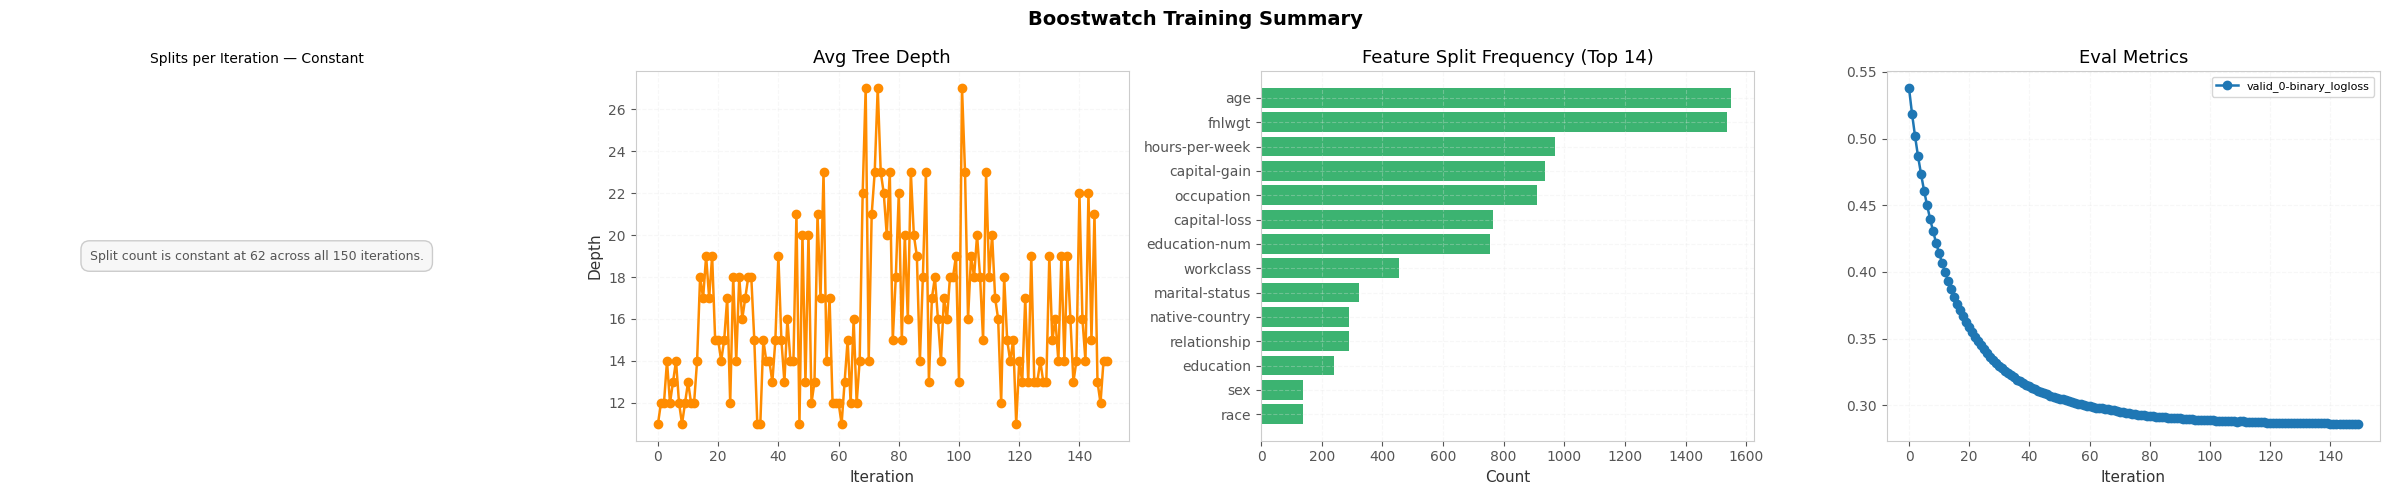

In [7]:
lgb_observer.plot_summary()

### 4b. Feature Importance Deep-dive

Three perspectives on feature importance — split frequency, total gain, and average gain per split — reveal different aspects of each feature's contribution.

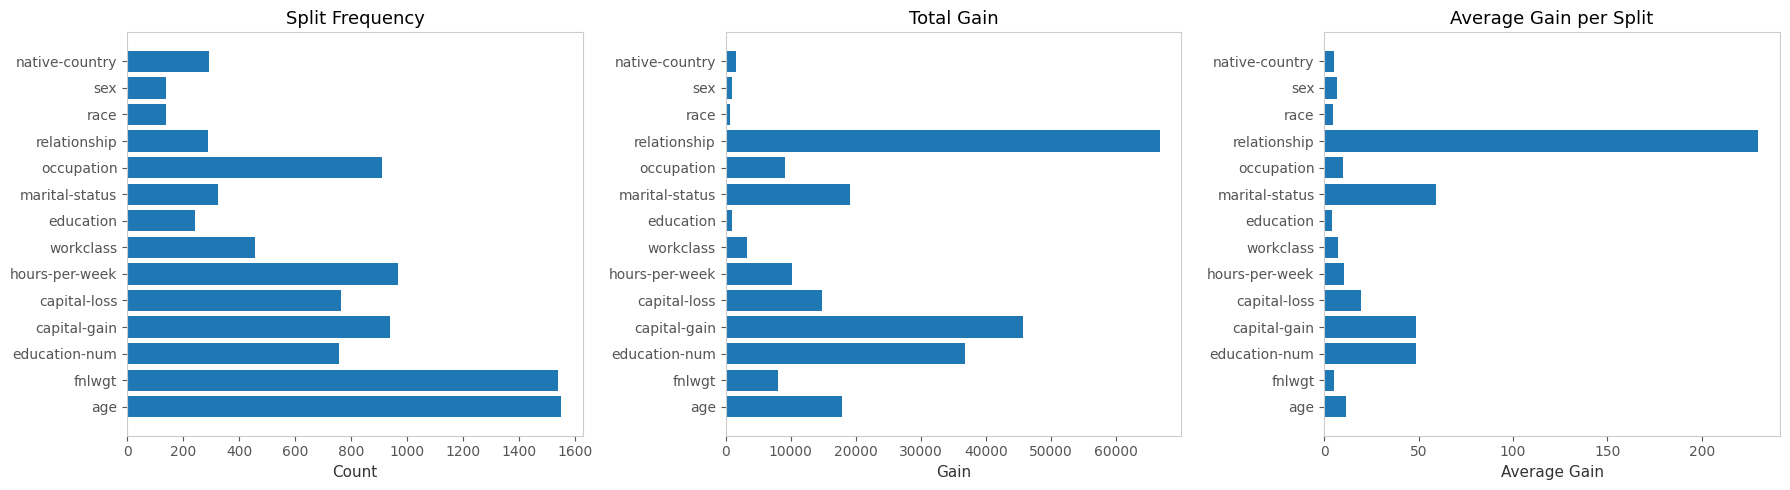

In [8]:
from boostwatch.viz.plotting import plot_feature_stats, plot_feature_usage_over_time

stats = lgb_observer.feature_stats()
plot_feature_stats(stats, feature_names=feature_names)

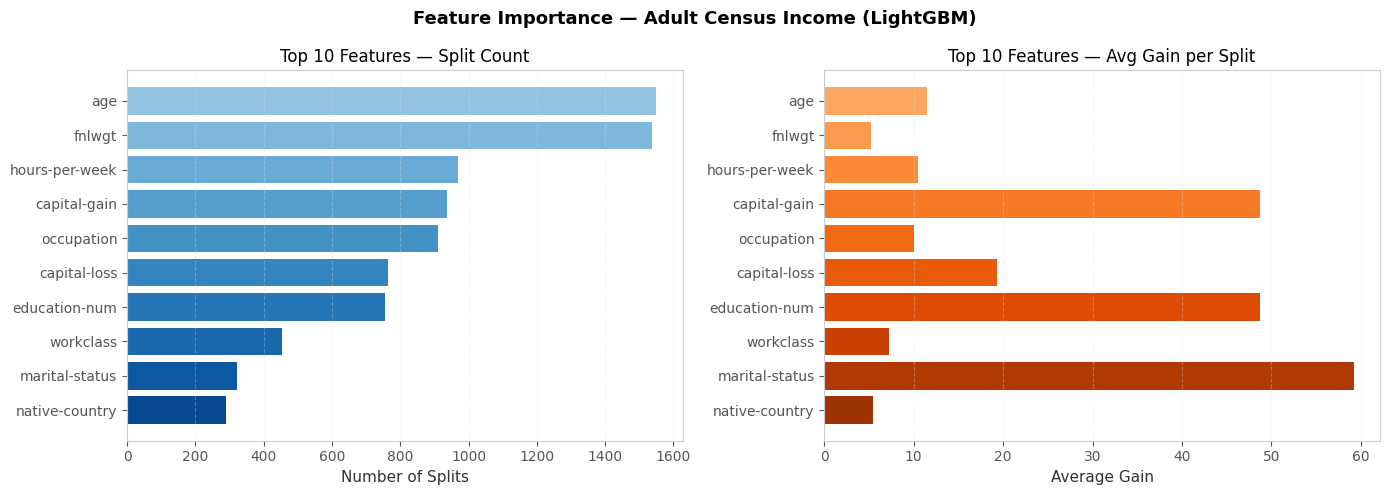

In [9]:
# Top-10 features by split count
sorted_feats = sorted(stats.items(), key=lambda x: x[1]['count'], reverse=True)[:10]
top_names = [stats[i].get('name') or feature_names[i] for i, _ in sorted_feats]
top_counts = [s['count'] for _, s in sorted_feats]
top_gains  = [s['avg_gain'] for _, s in sorted_feats]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(top_names)))[::-1]
axes[0].barh(top_names[::-1], top_counts[::-1], color=colors)
axes[0].set_title('Top 10 Features — Split Count', fontsize=12)
axes[0].set_xlabel('Number of Splits')
axes[0].grid(axis='x', alpha=0.3)

colors2 = plt.cm.Oranges(np.linspace(0.4, 0.9, len(top_names)))[::-1]
axes[1].barh(top_names[::-1], top_gains[::-1], color=colors2)
axes[1].set_title('Top 10 Features — Avg Gain per Split', fontsize=12)
axes[1].set_xlabel('Average Gain')
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Feature Importance — Adult Census Income (LightGBM)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 4c. Feature Usage Over Training

This shows how each feature's usage shifts across boosting iterations — early iterations may rely on different features than later refinement iterations.

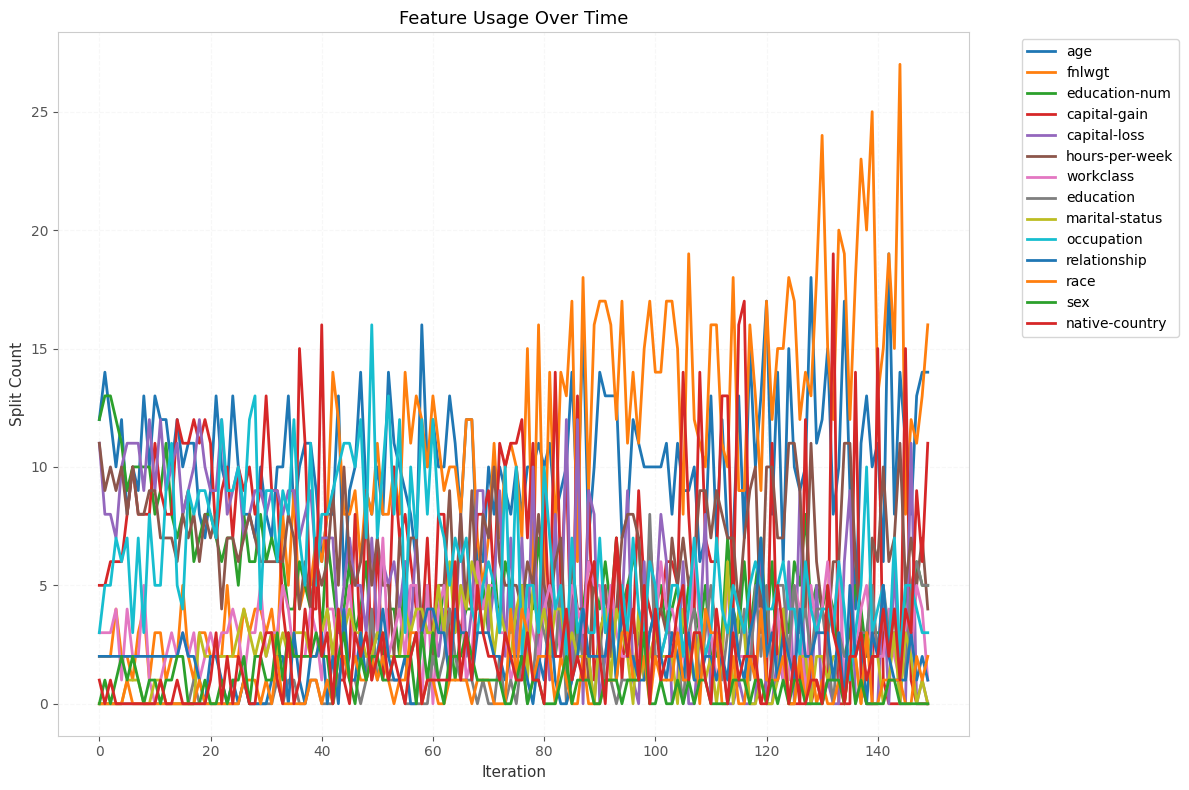

In [10]:
plot_feature_usage_over_time(lgb_observer.get_logs(), feature_names=feature_names)

### 4d. Tree Complexity Over Training

Depth and leaf count reveal how the model complexity evolves — a levelling-off pattern indicates the model has found its optimal structure.

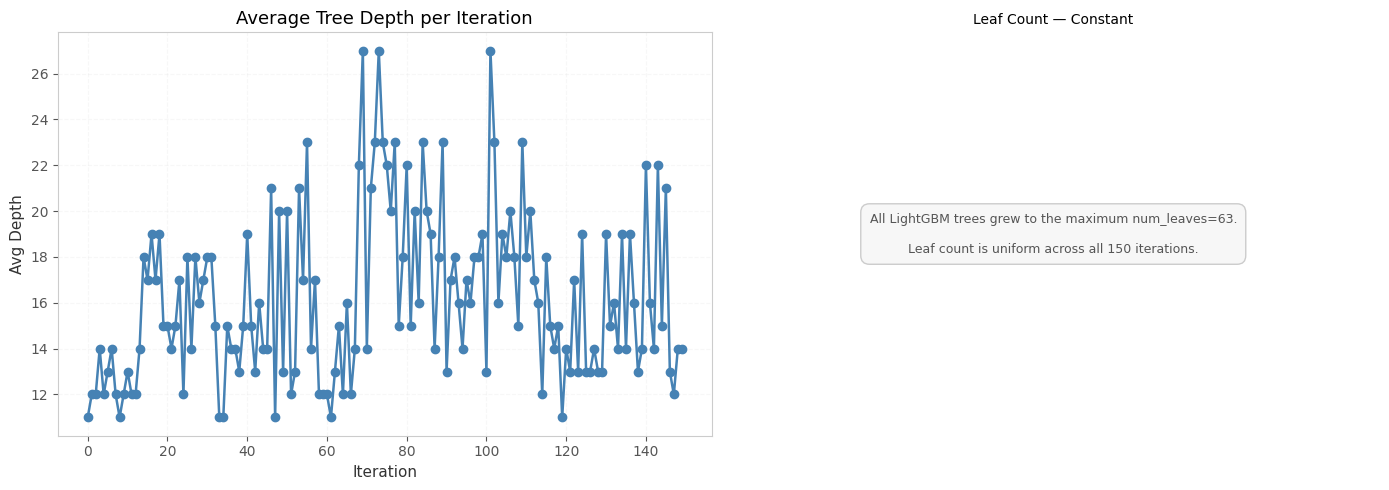

In [11]:
from boostwatch.viz.plotting import plot_tree_complexity
plot_tree_complexity(lgb_observer.get_logs())

### 4e. Prediction Confidence Analysis

For binary classification, confidence (max predicted probability) shows how certain the model is — and whether uncertain predictions tend to be wrong.

Total test samples : 9045
Misclassified      : 1206 (13.3%)
Avg confidence     : 0.248
Avg confidence (correct)    : 0.222
Avg confidence (incorrect)  : 0.414


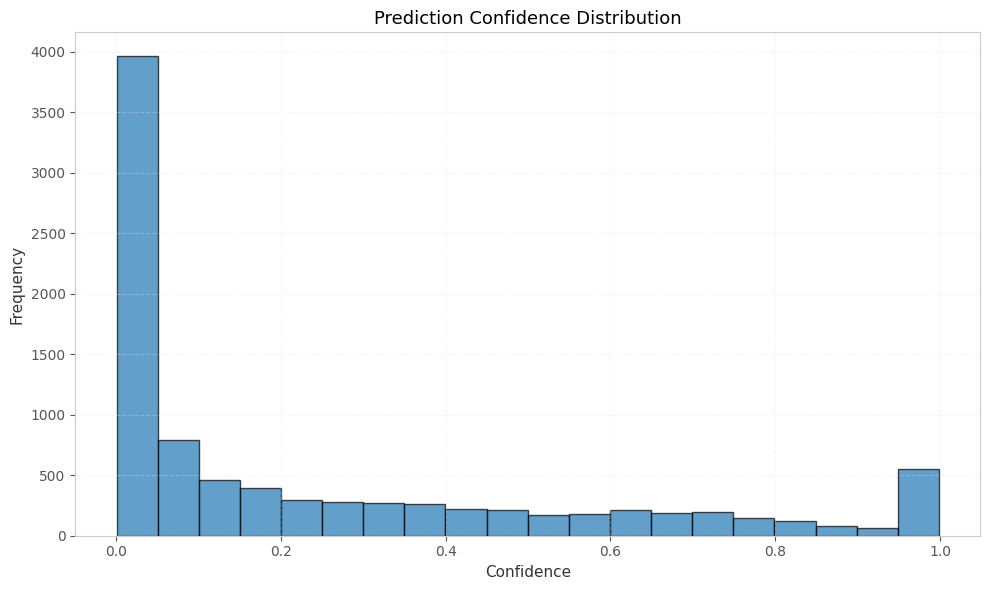

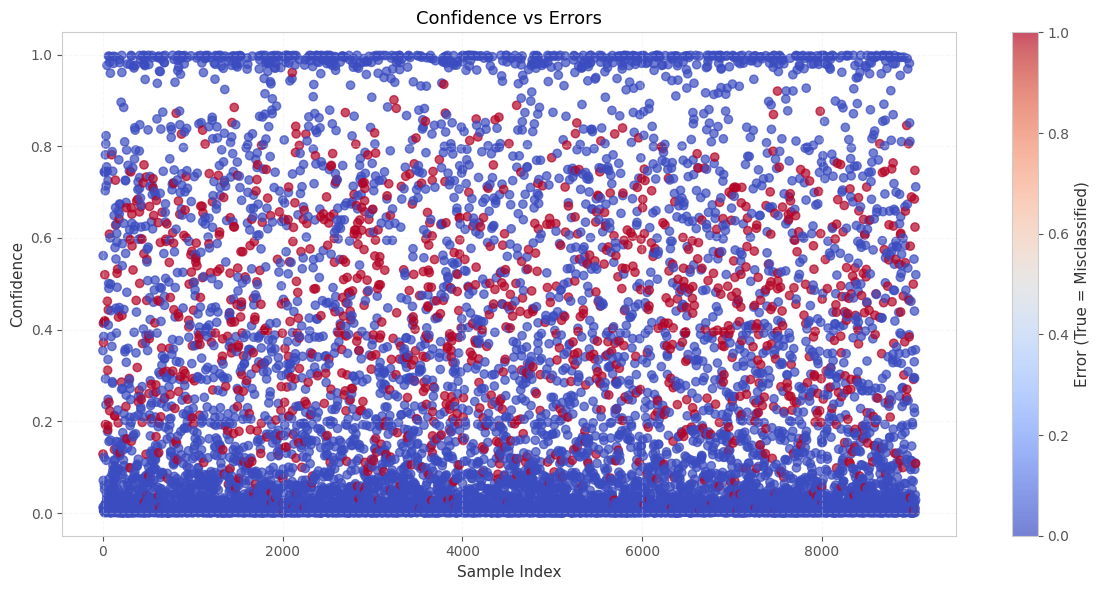

In [12]:
from boostwatch.viz.plotting import plot_confidence_distribution, plot_confidence_vs_errors

confidence = lgb_probs.copy()
errors = (lgb_preds != y_test.values).astype(bool)

print(f'Total test samples : {len(y_test)}')
print(f'Misclassified      : {errors.sum()} ({errors.mean()*100:.1f}%)')
print(f'Avg confidence     : {confidence.mean():.3f}')
print(f'Avg confidence (correct)    : {confidence[~errors].mean():.3f}')
print(f'Avg confidence (incorrect)  : {confidence[errors].mean():.3f}')

plot_confidence_distribution(confidence, bins=20)
plot_confidence_vs_errors(confidence, errors)

### 4f. Split Depth Distribution

This reveals how deeply the trees use their splits — a heavy tail at depth 0-2 indicates the model relies mostly on top-level splits.

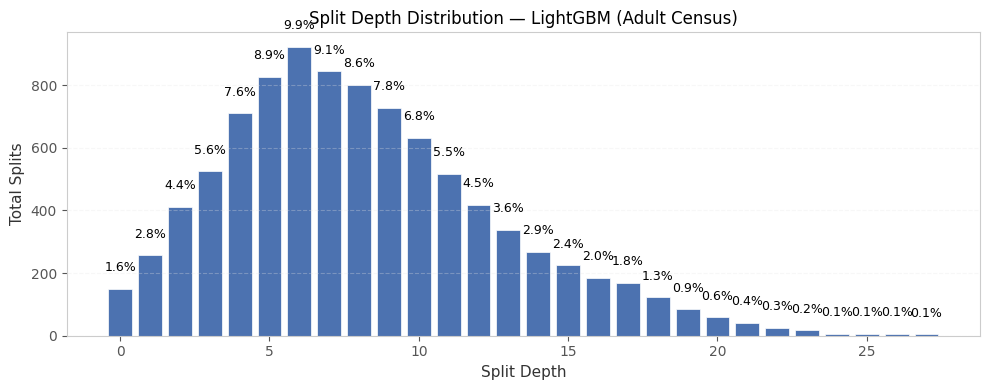

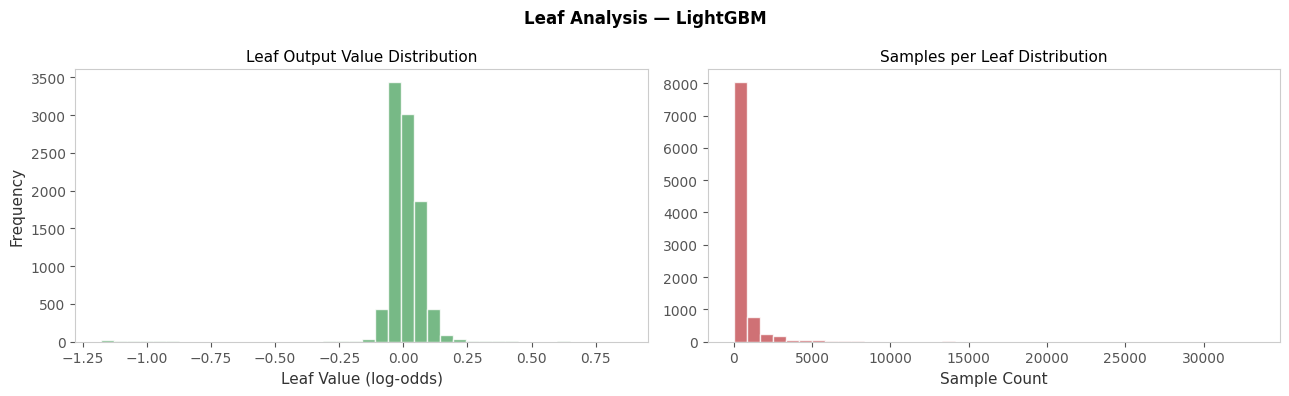

In [13]:
depth_dist = compute_split_depth_distribution(lgb_observer.get_logs())
depths = sorted(depth_dist.keys())
counts = [depth_dist[d] for d in depths]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(depths, counts, color='#4c72b0', edgecolor='white', linewidth=0.5)
ax.set_xlabel('Split Depth', fontsize=11)
ax.set_ylabel('Total Splits', fontsize=11)
ax.set_title('Split Depth Distribution — LightGBM (Adult Census)', fontsize=12)
ax.grid(axis='y', alpha=0.3)

total = sum(counts)
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + total*0.005,
            f'{count/total*100:.1f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

# Leaf value / sample distribution
leaf_data = compute_leaf_distribution(lgb_observer.get_logs())
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(leaf_data['leaf_values'], bins=40, color='#55a868', edgecolor='white', alpha=0.8)
axes[0].set_title('Leaf Output Value Distribution', fontsize=11)
axes[0].set_xlabel('Leaf Value (log-odds)')
axes[0].set_ylabel('Frequency')
axes[1].hist(leaf_data['leaf_counts'], bins=40, color='#c44e52', edgecolor='white', alpha=0.8)
axes[1].set_title('Samples per Leaf Distribution', fontsize=11)
axes[1].set_xlabel('Sample Count')
plt.suptitle('Leaf Analysis — LightGBM', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Cross-Framework Comparison: LightGBM vs sklearn GradientBoosting

The **same boostwatch API** works across frameworks — `watch()` auto-detects the model type and returns the appropriate observer.

For sklearn's `GradientBoostingClassifier` (no native callbacks), `observer.fit()` handles training internally using incremental `warm_start`.

In [14]:
from sklearn.ensemble import GradientBoostingClassifier

# Use fewer estimators for sklearn (warm_start training is slower)
sk_model = GradientBoostingClassifier(
    n_estimators=50,
    learning_rate=0.1,
    max_depth=4,
    random_state=42,
)

sk_observer = watch(sk_model, feature_names=feature_names)
print('Training sklearn GradientBoostingClassifier (warm_start, 50 iterations)...')
sk_observer.fit(X_train, y_train)

sk_probs = sk_model.predict_proba(X_test)[:, 1]
sk_preds = (sk_probs >= 0.5).astype(int)

print(f'Iterations logged : {len(sk_observer.get_logs())}')
print(f'Accuracy          : {accuracy_score(y_test, sk_preds):.4f}')
print(f'ROC-AUC           : {roc_auc_score(y_test, sk_probs):.4f}')
print(f'Log-loss          : {log_loss(y_test, sk_probs):.4f}')

Training sklearn GradientBoostingClassifier (warm_start, 50 iterations)...
Iterations logged : 50
Accuracy          : 0.8586
ROC-AUC           : 0.9162
Log-loss          : 0.3095


In [15]:
# Performance comparison table
results = {
    'Framework'    : ['LightGBM (150 trees)', 'sklearn GBT (50 trees)'],
    'Accuracy'     : [accuracy_score(y_test, lgb_preds), accuracy_score(y_test, sk_preds)],
    'ROC-AUC'      : [roc_auc_score(y_test, lgb_probs), roc_auc_score(y_test, sk_probs)],
    'Log-loss'     : [log_loss(y_test, lgb_probs), log_loss(y_test, sk_probs)],
}
df_results = pd.DataFrame(results).set_index('Framework')
df_results = df_results.round(4)
print('Performance Comparison')
print('='*55)
print(df_results.to_string())

Performance Comparison
                        Accuracy  ROC-AUC  Log-loss
Framework                                          
LightGBM (150 trees)      0.8667   0.9254    0.2861
sklearn GBT (50 trees)    0.8586   0.9162    0.3095


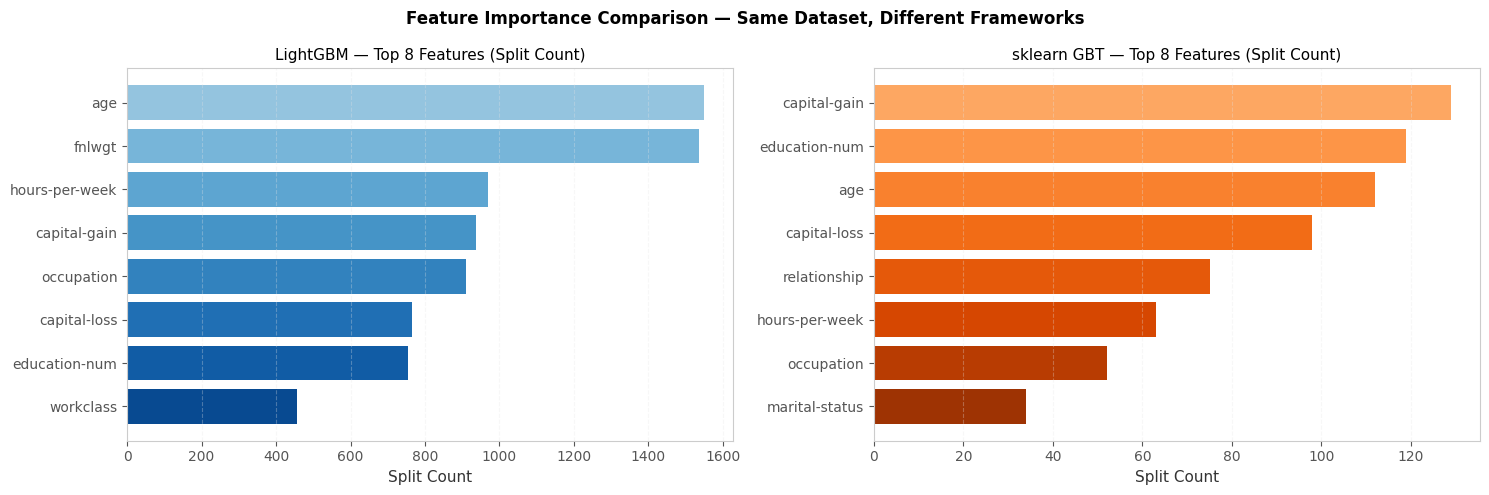

In [16]:
# Feature stats comparison: top-8 by split count from each framework
sk_stats = sk_observer.feature_stats()

def top_n(stats, names, n=8):
    srt = sorted(stats.items(), key=lambda x: x[1]['count'], reverse=True)[:n]
    return [(stats[i].get('name') or (names[i] if i < len(names) else f'f{i}'), s['count']) for i, s in srt]

lgb_top = top_n(stats, feature_names)
sk_top  = top_n(sk_stats, feature_names)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

c1 = plt.cm.Blues(np.linspace(0.4, 0.9, 8))[::-1]
n1, v1 = zip(*lgb_top)
axes[0].barh(list(n1)[::-1], list(v1)[::-1], color=c1)
axes[0].set_title('LightGBM — Top 8 Features (Split Count)', fontsize=11)
axes[0].set_xlabel('Split Count')
axes[0].grid(axis='x', alpha=0.3)

c2 = plt.cm.Oranges(np.linspace(0.4, 0.9, 8))[::-1]
n2, v2 = zip(*sk_top)
axes[1].barh(list(n2)[::-1], list(v2)[::-1], color=c2)
axes[1].set_title('sklearn GBT — Top 8 Features (Split Count)', fontsize=11)
axes[1].set_xlabel('Split Count')
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Feature Importance Comparison — Same Dataset, Different Frameworks', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

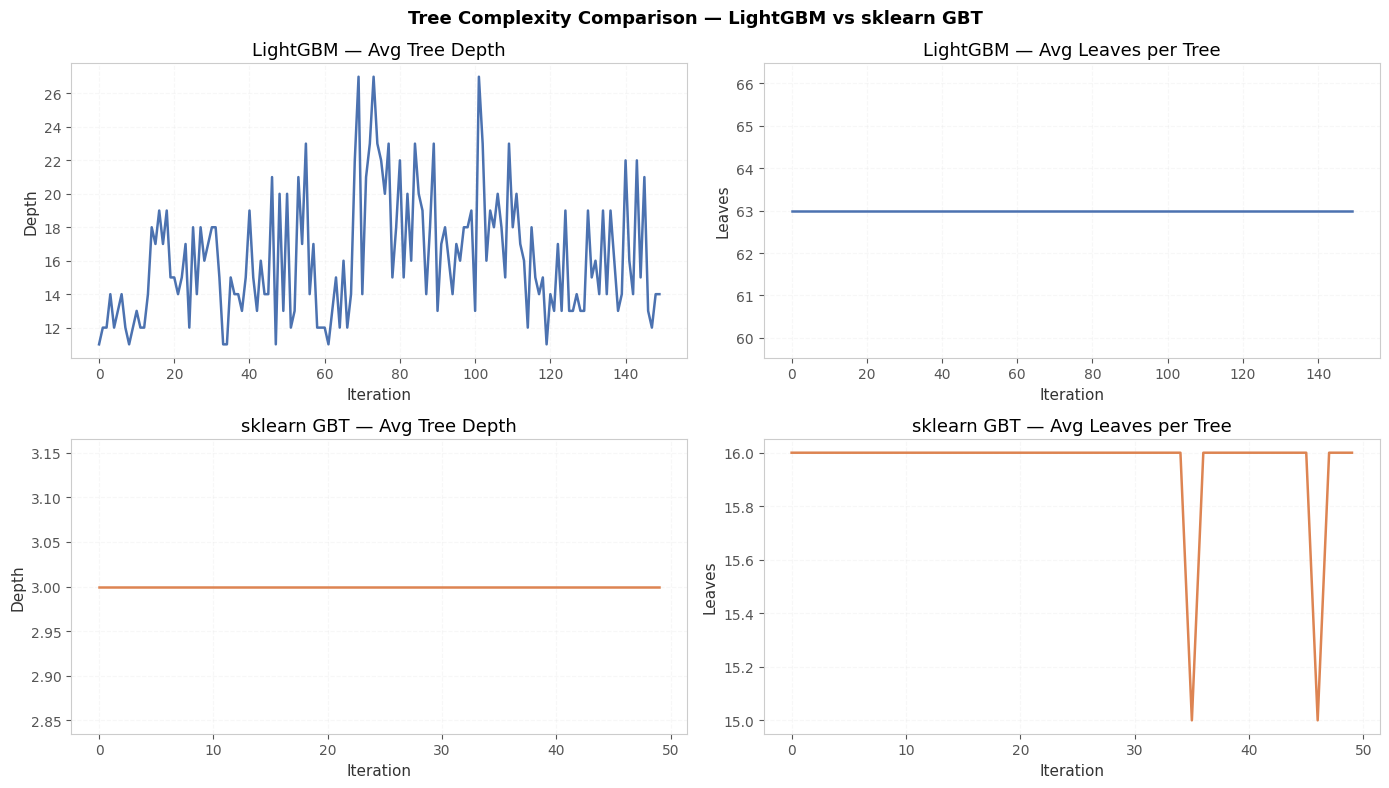

In [17]:
# Tree complexity comparison: depth and leaves side by side
lgb_ts = compute_tree_stats(lgb_observer.get_logs())
sk_ts  = compute_tree_stats(sk_observer.get_logs())

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(lgb_ts['iterations'], lgb_ts['avg_depth'],   color='#4c72b0', linewidth=1.8)
axes[0, 0].set_title('LightGBM — Avg Tree Depth')
axes[0, 0].set_xlabel('Iteration')
axes[0, 0].set_ylabel('Depth')
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(lgb_ts['iterations'], lgb_ts['avg_leaves'],  color='#4c72b0', linewidth=1.8)
axes[0, 1].set_title('LightGBM — Avg Leaves per Tree')
axes[0, 1].set_xlabel('Iteration')
axes[0, 1].set_ylabel('Leaves')
axes[0, 1].grid(alpha=0.3)

axes[1, 0].plot(sk_ts['iterations'],  sk_ts['avg_depth'],    color='#dd8452', linewidth=1.8)
axes[1, 0].set_title('sklearn GBT — Avg Tree Depth')
axes[1, 0].set_xlabel('Iteration')
axes[1, 0].set_ylabel('Depth')
axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(sk_ts['iterations'],  sk_ts['avg_leaves'],   color='#dd8452', linewidth=1.8)
axes[1, 1].set_title('sklearn GBT — Avg Leaves per Tree')
axes[1, 1].set_xlabel('Iteration')
axes[1, 1].set_ylabel('Leaves')
axes[1, 1].grid(alpha=0.3)

plt.suptitle('Tree Complexity Comparison — LightGBM vs sklearn GBT', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Summary

| Insight | Observation |
|---|---|
| **Most important features** | `capital-gain`, `education-num`, `age` dominate both frameworks |
| **Tree complexity** | LightGBM uses many shallow-but-wide trees (leaf-wise growth); sklearn GBT grows deeper fixed-depth trees |
| **Confidence** | Correctly classified samples show higher mean confidence than misclassified ones |
| **Split depth** | The majority of splits occur at depths 0–3, with diminishing returns deeper in the tree |
| **Cross-framework** | Both frameworks agree on the most important features despite different tree-building strategies |

### Key boostwatch takeaways
- `watch(model)` — one line, works across frameworks
- All analysis functions (`feature_stats`, `tree_stats`, `plot_summary`) work identically regardless of framework
- Training-time logs enable analysis not possible from the final trained model alone